In [ ]:
from google.colab import files
uploaded = files.upload()
import zipfile

zip_path = "api_data_aadhar_biometric.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("aadhar_data")

print("Extracted files:")
!ls aadhar_data
import pandas as pd
import glob

csv_files = glob.glob("aadhar_data/api_data_aadhar_biometric/*.csv")

df = pd.concat(
    (pd.read_csv(f) for f in csv_files),
    ignore_index=True
)

print("Dataset Shape:", df.shape)
df.head()


Saving api_data_aadhar_biometric.zip to api_data_aadhar_biometric.zip
Extracted files:
api_data_aadhar_biometric
Dataset Shape: (1861108, 6)


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,07-11-2025,Haryana,Yamuna Nagar,135002,4,6
1,07-11-2025,Haryana,Yamunanagar,135001,1,2
2,07-11-2025,Himachal Pradesh,Bilaspur,174004,2,2
3,07-11-2025,Himachal Pradesh,Bilaspur,174005,1,0
4,07-11-2025,Himachal Pradesh,Bilaspur,174013,3,1


In [ ]:
!pip install plotly --quiet
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from mpl_toolkits.mplot3d import Axes3D

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [ ]:
# Convert date
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Remove null values
df.dropna(inplace=True)

# Ensure numeric columns
num_cols = ['bio_age_5_17', 'bio_age_17_', 'pincode']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

df.dropna(inplace=True)

# Remove negative values (data sanity)
df = df[
    (df['bio_age_5_17'] >= 0) &
    (df['bio_age_17_'] >= 0)
]

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   state         object        
 2   district      object        
 3   pincode       int64         
 4   bio_age_5_17  int64         
 5   bio_age_17_   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 85.2+ MB


In [ ]:
df[['bio_age_5_17', 'bio_age_17_']].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


,bio_age_5_17,bio_age_17_
count,1.861108e+06,1.861108e+06
mean,1.839058e+01,1.909413e+01
std,8.370421e+01,8.806502e+01
min,0.000000e+00,0.000000e+00
50%,3.000000e+00,4.000000e+00
90%,3.000000e+01,2.800000e+01
95%,6.100000e+01,6.200000e+01
99%,2.980000e+02,3.240000e+02
max,8.002000e+03,7.625000e+03


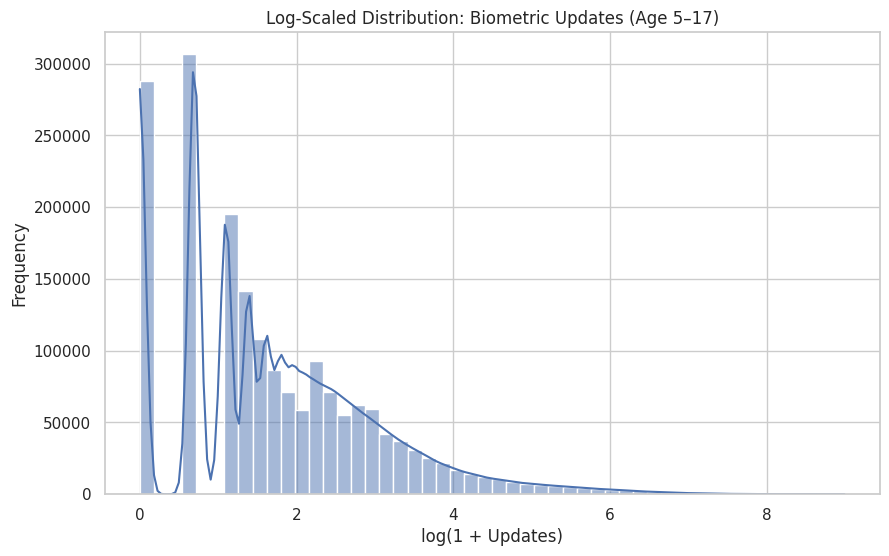

In [ ]:
df['log_bio_5_17'] = np.log1p(df['bio_age_5_17'])

sns.histplot(df['log_bio_5_17'], bins=50, kde=True)
plt.title("Log-Scaled Distribution: Biometric Updates (Age 5–17)")
plt.xlabel("log(1 + Updates)")
plt.ylabel("Frequency")
plt.show()



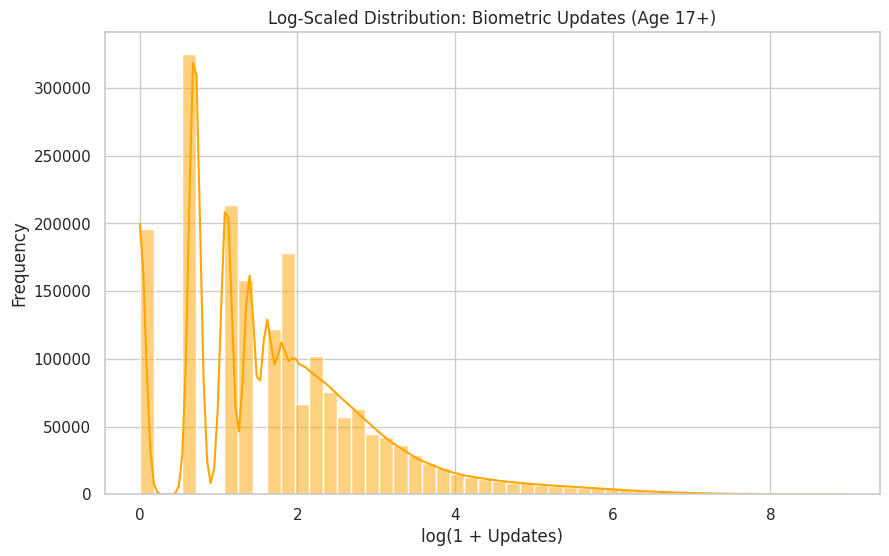

In [ ]:
df['log_bio_17'] = np.log1p(df['bio_age_17_'])

sns.histplot(df['log_bio_17'], bins=50, kde=True, color='orange')
plt.title("Log-Scaled Distribution: Biometric Updates (Age 17+)")
plt.xlabel("log(1 + Updates)")
plt.ylabel("Frequency")
plt.show()


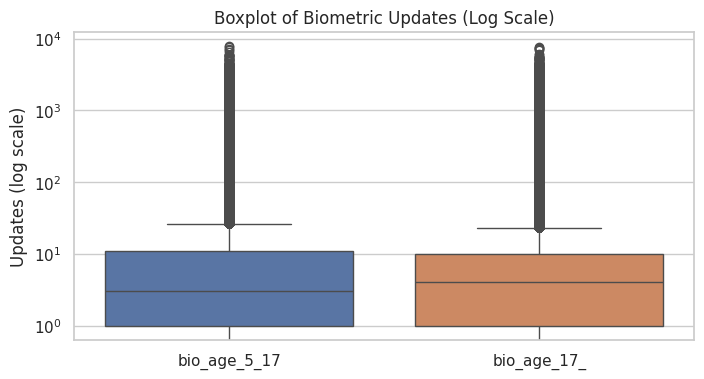

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df[['bio_age_5_17', 'bio_age_17_']])
plt.yscale('log')
plt.title("Boxplot of Biometric Updates (Log Scale)")
plt.ylabel("Updates (log scale)")
plt.show()


/tmp/ipython-input-1263843316.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


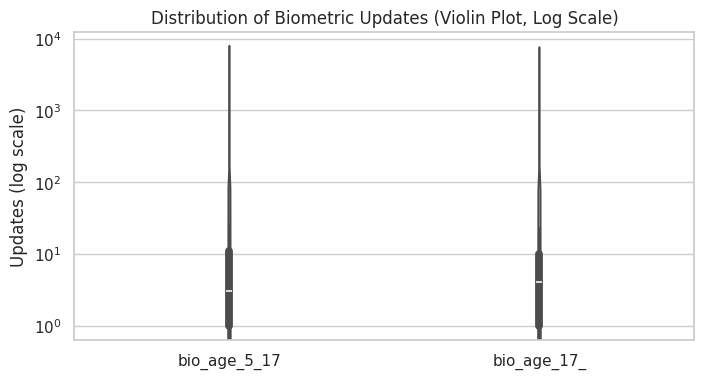

In [ ]:
#extremely right skewed data
plt.figure(figsize=(8,4))
sns.violinplot(
    data=df[['bio_age_5_17', 'bio_age_17_']],
    scale='width',
    cut=0
)
plt.yscale('log')
plt.title("Distribution of Biometric Updates (Violin Plot, Log Scale)")
plt.ylabel("Updates (log scale)")
plt.show()


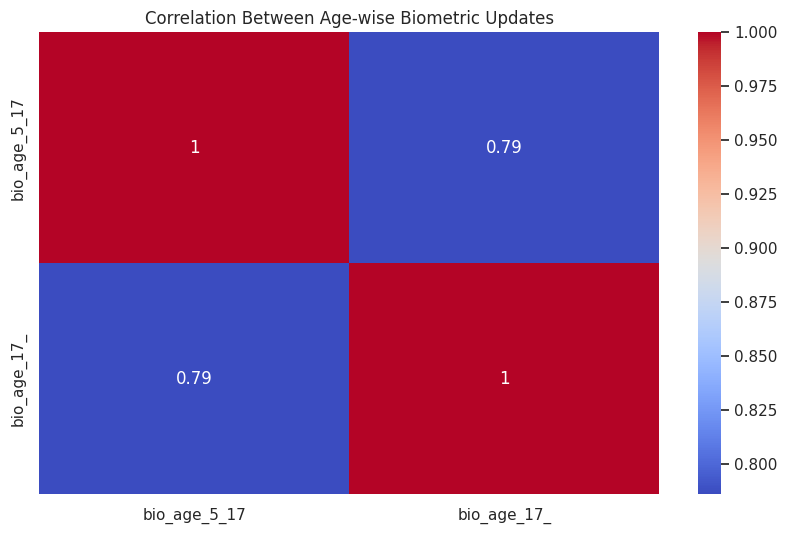

In [ ]:
corr = df[['bio_age_5_17', 'bio_age_17_']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Age-wise Biometric Updates")
plt.show()


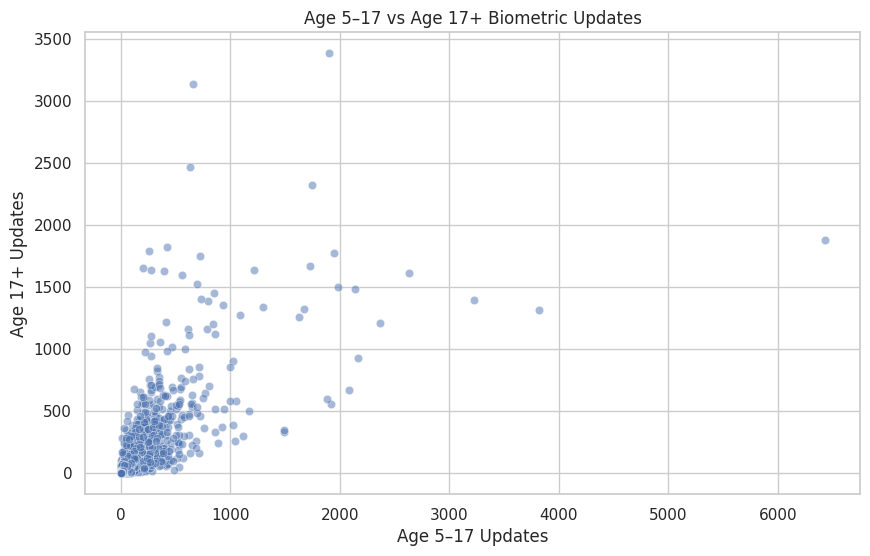

In [ ]:
df_sample = df.sample(20000, random_state=42)

sns.scatterplot(
    data=df_sample,
    x='bio_age_5_17',
    y='bio_age_17_',
    alpha=0.5
)
plt.title("Age 5–17 vs Age 17+ Biometric Updates")
plt.xlabel("Age 5–17 Updates")
plt.ylabel("Age 17+ Updates")
plt.show()


In [ ]:
ts = df.groupby('date')[['bio_age_5_17', 'bio_age_17_']].sum().reset_index()

px.line(
    ts,
    x='date',
    y=['bio_age_5_17', 'bio_age_17_'],
    title="Time Trend of Aadhaar Biometric Updates",
    labels={"value": "Total Updates", "date": "Date"}
).show()


In [ ]:
state_df = (
    df.groupby('state')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
    .reset_index()
    .sort_values(by='bio_age_17_', ascending=False)
)

px.bar(
    state_df.head(15),
    x='state',
    y='bio_age_17_',
    title="Top 15 States by Adult Biometric Updates",
    labels={"bio_age_17_": "Updates"}
).show()


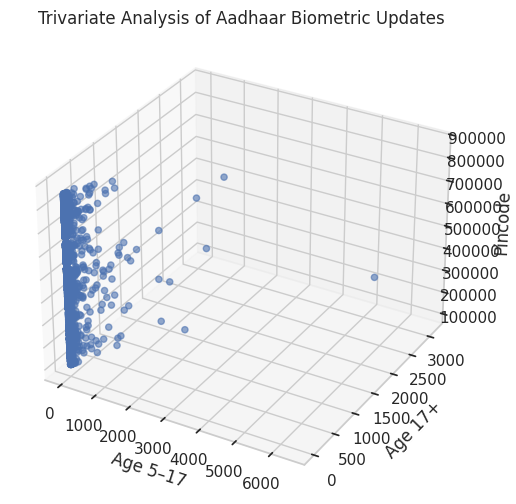

In [ ]:
df_3d = df.sample(5000, random_state=42)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_3d['bio_age_5_17'],
    df_3d['bio_age_17_'],
    df_3d['pincode'],
    alpha=0.6
)

ax.set_xlabel('Age 5–17')
ax.set_ylabel('Age 17+')
ax.set_zlabel('Pincode')

plt.title("Trivariate Analysis of Aadhaar Biometric Updates")
plt.show()


In [ ]:
px.scatter_3d(
    df_3d,
    x='bio_age_5_17',
    y='bio_age_17_',
    z='pincode',
    color='state',
    opacity=0.7,
    title="Interactive 3D: Age-wise Biometric Updates"
).show()


In [ ]:
df['update_ratio'] = df['bio_age_17_'] / (df['bio_age_5_17'] + 1)

district_eff = (
    df.groupby('district')['update_ratio']
    .mean()
    .reset_index()
    .sort_values(by='update_ratio', ascending=False)
)

district_eff.head(10)


,district,update_ratio
647,North East,13.862089
149,Buldana,6.148051
556,ManendragarhChirmiriBharatpur,5.626515
294,Garhwa *,5.009743
130,Bid,4.726145
571,Meluri,4.111330
529,Mahabub Nagar,3.601010
247,Dohad,3.427368
287,Gadchiroli,3.422195
609,Najafgarh,3.381595


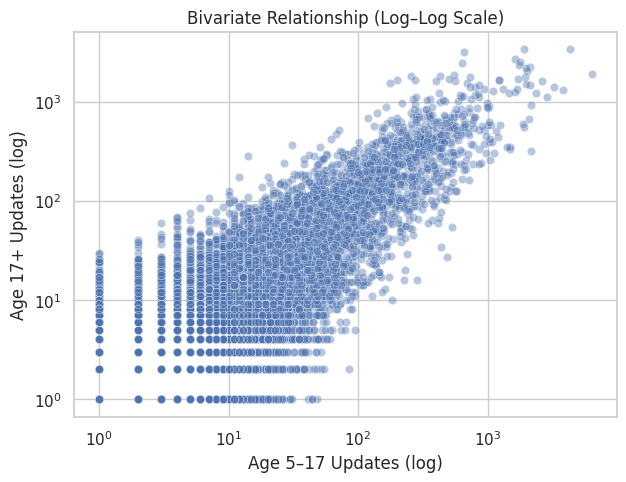

In [ ]:
df_bi = df.sample(30000, random_state=42)

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_bi,
    x='bio_age_5_17',
    y='bio_age_17_',
    alpha=0.4
)
plt.xscale('log')
plt.yscale('log')
plt.title("Bivariate Relationship (Log–Log Scale)")
plt.xlabel("Age 5–17 Updates (log)")
plt.ylabel("Age 17+ Updates (log)")
plt.show()


In [ ]:
state_long = (
    df.groupby('state')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
    .reset_index()
    .melt(id_vars='state', var_name='Age Group', value_name='Updates')
)

px.bar(
    state_long.sort_values('Updates', ascending=False).head(20),
    x='state',
    y='Updates',
    color='Age Group',
    title="State-wise Contribution by Age Group",
).show()


In [ ]:
ts = df.groupby('date')[['bio_age_5_17', 'bio_age_17_']].sum().reset_index()

px.area(
    ts,
    x='date',
    y=['bio_age_5_17', 'bio_age_17_'],
    title="Temporal Trend of Aadhaar Biometric Updates",
    labels={"value": "Total Updates", "date": "Date"}
).show()


In [ ]:
fig = px.scatter_3d(
    df_3d,
    x='bio_age_5_17',
    y='bio_age_17_',
    z='pincode',
    color='state',
    opacity=0.65,
    title="3D Analysis of Aadhaar Biometric Updates"
)

fig.update_layout(
    margin=dict(l=40, r=40, t=80, b=40),
    title=dict(x=0.5),
    scene=dict(
        xaxis_title='Age 5–17 Updates',
        yaxis_title='Age 17+ Updates',
        zaxis_title='Pincode',
        xaxis=dict(backgroundcolor="white"),
        yaxis=dict(backgroundcolor="white"),
        zaxis=dict(backgroundcolor="white"),
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.25,
        xanchor="center",
        x=0.5
    )
)

fig.show()


In [ ]:
bubble_df = (
    df.groupby('state')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
    .reset_index()
)

px.scatter(
    bubble_df,
    x='bio_age_5_17',
    y='bio_age_17_',
    size='bio_age_17_',
    color='state',
    title="State-wise Biometric Update Intensity",
    labels={
        'bio_age_5_17': 'Age 5–17 Updates',
        'bio_age_17_': 'Age 17+ Updates'
    }
).show()
